<a href="https://colab.research.google.com/github/Thomas-Fabbris/MMIP-polimi/blob/main/Assignments/lecture_11_gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import numpy as np
from matplotlib import pyplot as plt

Define the problem parameters


In [35]:
A = np.array([[1, 3], [3, 1]])
b = np.array([1.1, 0.2])

The function to be minimized is $f(x) = \frac{1}{2}\|Ax-b\|_2^2$

In [36]:
def f(x): return 0.5 * np.sum((A @ x - b) ** 2)

# Derivative of f


def df(x): return A.T @ (A @ x - b)

Plot the function $f(x)$

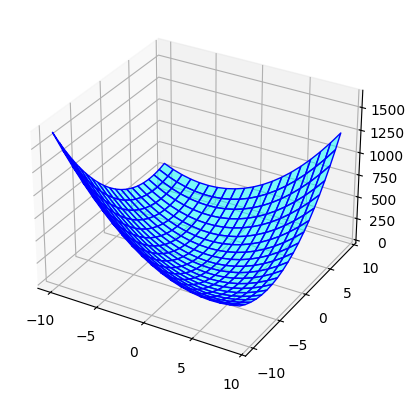

In [43]:
def F(r1, r2): return 0.5 * ((r1 * A[0, 0] + r2 * A[0, 1] -
                              b[0]) ** 2 + (r1 * A[1, 0] + r2 * A[1, 1] - b[1]) ** 2)


xx, yy = np.meshgrid(np.arange(-10, 10), np.arange(-10, 10))

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(xx, yy, F(xx, yy), edgecolor=[
                0, 0, 1], alpha=0.5, facecolor=[0, 1, 1])

Gradient descent algorithm parameters

In [38]:
TOL_GRAD_NORM = 1e-5
MAX_ITER = 100
TOL_DIST = 1e-4
alpha = 0.05            # Step size

Initialization  
Test different inizializations for $x$: $f$ is convex, so you always 
converge to the same solution

In [ ]:
x = np.array([-5, 10])
# x = np.zeros_like(b)

grad_norm = 1e10
distanceX = 1e10

# Initialize the list with all the estimates
all_x = [x]

Main loop

In [ ]:
cnt = 0

while grad_norm > TOL_GRAD_NORM and cnt < MAX_ITER and distanceX > TOL_DIST:
    cnt = cnt + 1
    # Gradient descent step
    x = x - alpha * df(x)

    # Compute gradient at NEW x (for stopping criterion)
    grad_norm = np.linalg.norm(df(x))

    # Compute the distance between two consecutive iterates for the stopping criteria
    distanceX = np.linalg.norm(x - all_x[-1])

    # Store the estimate
    all_x.append(x)

Plot all the estimates

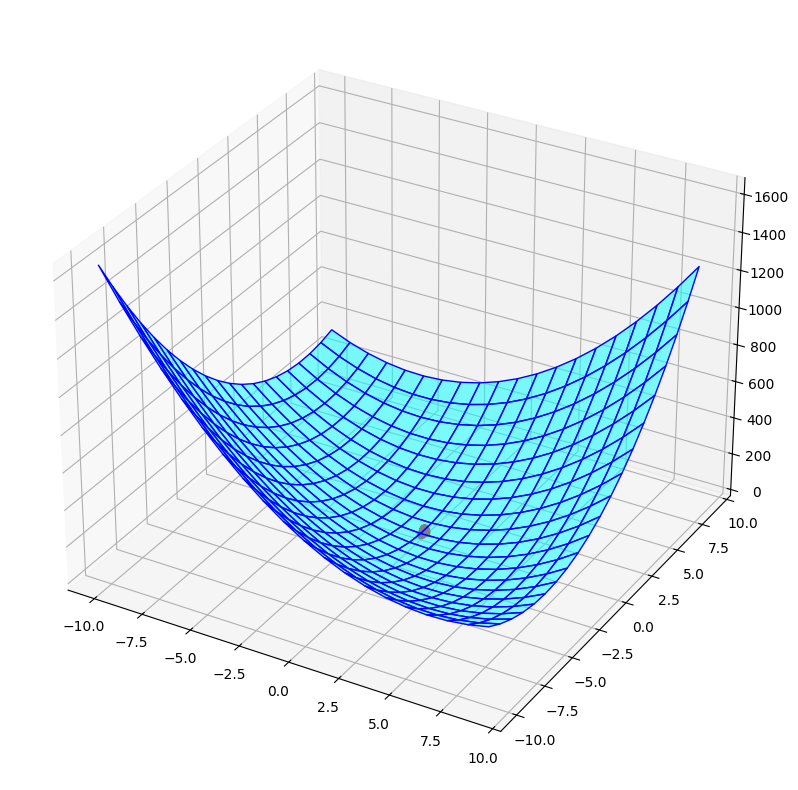

In [54]:
# Plot the new estimate
xxplot = [x[0] for x in all_x]
yyplot = [x[1] for x in all_x]
zzplot = F(np.array(xxplot), np.array(yyplot))

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection='3d')
ax.plot_surface(xx, yy, F(xx, yy), edgecolor=[
                0, 0, 1], alpha=0.5, facecolor=[0, 1, 1])
ax.plot3D(xxplot, yyplot, zzplot, 'r-o')